In [2]:
"""
Example: Visual Question Answering (VQA) with Green-VLA.

The underlying VLM backbone can answer free-form questions about images.
This notebook defines a simple `vqa()` helper and demonstrates its usage.
"""

from PIL import Image
import requests
import torch

from lerobot.common.policies.factory import load_pretrained_policy

# Load the policy without data transforms (not needed for VQA).
MODEL_ID = "SberRoboticsCenter/GreenVLA-5b-base-stride-1"
#MODEL_ID = "SberRoboticsCenter/GreenVLA-2b-base"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

policy, _, _ = load_pretrained_policy(MODEL_ID, data_config_name=None)
policy = policy.to(DEVICE).eval()

config.json: 0.00B [00:00, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

pretrained_model/model.safetensors:   0%|          | 0.00/10.8G [00:00<?, ?B/s]

In [3]:
@torch.no_grad()
def vqa(
    policy,
    image: Image.Image,
    prompt: str,
    *,
    max_new_tokens: int = 256,
    do_sample: bool = False,
    max_input_length: int = 256,
) -> str:
    """Run visual question answering on a single image.

    Args:
        policy: A loaded GreenVLAPolicy (already on the target device).
        image: A PIL Image (any size; the processor handles resizing).
        prompt: The question or instruction (e.g. "Describe the scene").
        max_new_tokens: Maximum number of tokens to generate.
        do_sample: Whether to use sampling (False = greedy decoding).
        max_input_length: Max token length for the input context.

    Returns:
        The decoded text response from the model.
    """
    processor = policy.model.processor
    device = next(policy.parameters()).device

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": prompt},
            ],
        }
    ]

    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=False,
        return_dict=True,
        return_tensors="pt",
        padding_side="left",
        padding="max_length",
        max_length=max_input_length,
        images_kwargs={"do_resize": True},
    ).to(device)

    generated_ids = policy.model.model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,
        use_cache=False,
    )

    # Trim input tokens from the generated sequence and decode.
    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )
    return output_text[0]

## VQA

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


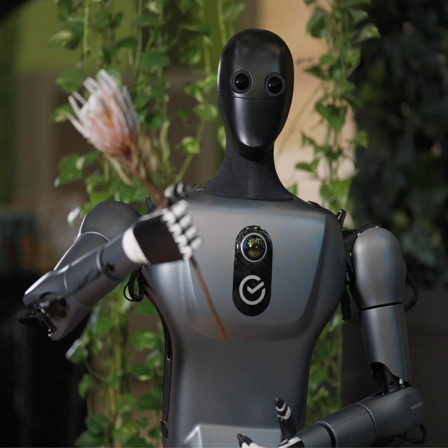

assistant
The image features a robot with a unique and interesting design, resembling a robot's head and arm. The robot is holding a flower, which adds a touch of nature to the scene. The robot's arm is extended, and it is positioned in such a way that it appears to be holding the flower. The overall composition of the image is quite intriguing and captivating, combining the robot's mechanical appearance with the delicate and delicate flower.


In [4]:
# Try another prompt on the same image
# Load a test image
img_url = "https://cdn-uploads.huggingface.co/production/uploads/642694c721d5f027bec07c71/cz33CQXXE3--u2_mmgA5G.png"
img = Image.open(requests.get(img_url, stream=True).raw).resize((448, 448))

answer = vqa(policy, img, "Briefly describe the image")
img.show()
print(answer)

## Bounding box detrection

In [5]:
# Try another prompt on the same image
# Load a test image
img_url = "https://cdn-uploads.huggingface.co/production/uploads/642694c721d5f027bec07c71/cz33CQXXE3--u2_mmgA5G.png"
img = Image.open(requests.get(img_url, stream=True).raw).resize((448, 448)) # The model was trained on 448x448 images, so we recommend resizing to this size.

answer = vqa(policy, img, 'Locate every instance that belongs to the following categories: \"flower, robot head, robot hand\". Report bbox coordinates in JSON format.')
print(answer)

assistant
```json
[
	{"bbox_2d": [130, 149, 320, 360], "label": "flower"},
	{"bbox_2d": [470, 60, 650, 459], "label": "robot head"},
	{"bbox_2d": [40, 440, 310, 769], "label": "robot hand"}
]
```


Detections: [{'bbox_2d': [130, 149, 320, 360], 'label': 'flower'}, {'bbox_2d': [470, 60, 650, 459], 'label': 'robot head'}, {'bbox_2d': [40, 440, 310, 769], 'label': 'robot hand'}]


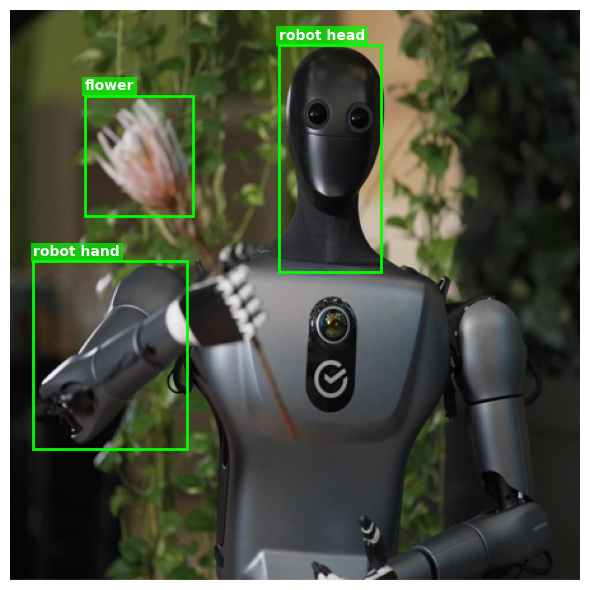

In [6]:
import json
import re
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def parse_bbox_answer(answer: str) -> list[dict]:
    """Parse the model's JSON response containing bounding boxes.

    The model returns text like:
        assistant
        ```json
        [{"bbox_2d": [x0, y0, x1, y1], "label": "..."}]
        ```

    Coordinates are normalised to the 0-1000 range.
    """
    # Extract the JSON block from the markdown-formatted answer.
    match = re.search(r"```json\s*(.*?)\s*```", answer, re.DOTALL)
    if match is None:
        raise ValueError(f"Could not find a JSON block in the answer:\n{answer}")
    return json.loads(match.group(1))


def plot_bboxes(image: Image.Image, detections: list[dict]) -> None:
    """Draw bounding boxes on the image.

    Args:
        image: The original PIL image.
        detections: List of dicts with ``bbox_2d`` ([x0,y0,x1,y1] in 0-1000)
                    and ``label`` keys.
    """
    w, h = image.size

    fig, ax = plt.subplots(1, figsize=(6, 6))
    ax.imshow(image)

    for det in detections:
        x0, y0, x1, y1 = det["bbox_2d"]
        # Scale from 0-1000 normalised coords to actual pixel coords.
        x0, x1 = x0 / 1000 * w, x1 / 1000 * w
        y0, y1 = y0 / 1000 * h, y1 / 1000 * h

        rect = patches.Rectangle(
            (x0, y0), x1 - x0, y1 - y0,
            linewidth=2, edgecolor="lime", facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(
            x0, y0 - 4, det.get("label", ""),
            color="white", fontsize=10, fontweight="bold",
            bbox=dict(facecolor="lime", alpha=0.7, pad=2, edgecolor="none"),
        )

    ax.axis("off")
    plt.tight_layout()
    plt.show()


# Parse the answer from the previous cell and visualise.
detections = parse_bbox_answer(answer)
print("Detections:", detections)
plot_bboxes(img, detections)

## Pointing

In [7]:
# Load a test image
img_url = "https://cdn-uploads.huggingface.co/production/uploads/642694c721d5f027bec07c71/cz33CQXXE3--u2_mmgA5G.png"
img = Image.open(requests.get(img_url, stream=True).raw).resize((448, 448))

answer = vqa(policy, img, "Point to all instances of flower, robot eyes, sber logo. Report coordinates in JSON format.")
print(answer)

assistant
```json
[
	{"point_2d": [243, 260], "label": "flower"},
	{"point_2d": [538, 180], "label": "robot eyes"},
	{"point_2d": [610, 188], "label": "robot eyes"},
	{"point_2d": [566, 640], "label": "sber logo"}
]
```


Detections: [{'point_2d': [243, 260], 'label': 'flower'}, {'point_2d': [538, 180], 'label': 'robot eyes'}, {'point_2d': [610, 188], 'label': 'robot eyes'}, {'point_2d': [566, 640], 'label': 'sber logo'}]


/tmp/ipykernel_122615/2886641979.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(len(unique_labels), 1))


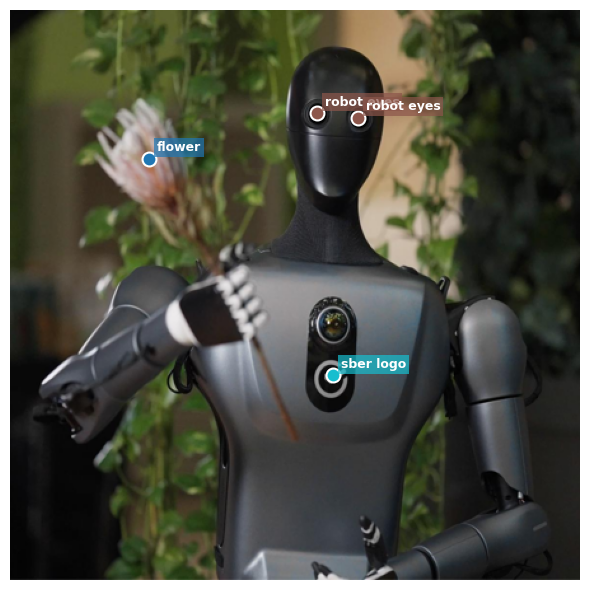

In [8]:
def plot_points(image: Image.Image, detections: list[dict]) -> None:
    """Draw predicted points on the image.

    Args:
        image: The original PIL image.
        detections: List of dicts with ``point_2d`` ([x, y] in 0-1000)
                    and ``label`` keys.
    """
    w, h = image.size

    fig, ax = plt.subplots(1, figsize=(6, 6))
    ax.imshow(image)

    # Assign a distinct colour per unique label.
    unique_labels = list(dict.fromkeys(d.get("label", "") for d in detections))
    cmap = plt.cm.get_cmap("tab10", max(len(unique_labels), 1))
    label_to_color = {label: cmap(i) for i, label in enumerate(unique_labels)}

    for det in detections:
        px, py = det["point_2d"]
        # Scale from 0-1000 normalised coords to actual pixel coords.
        px = px / 1000 * w
        py = py / 1000 * h
        label = det.get("label", "")
        color = label_to_color[label]

        ax.plot(px, py, marker="o", markersize=10, markeredgecolor="white",
                markeredgewidth=1.5, color=color)
        ax.text(
            px + 6, py - 6, label,
            color="white", fontsize=9, fontweight="bold",
            bbox=dict(facecolor=color, alpha=0.7, pad=2, edgecolor="none"),
        )

    ax.axis("off")
    plt.tight_layout()
    plt.show()


# Parse the answer from the previous cell and visualise.
points = parse_bbox_answer(answer)  # same JSON structure, different key
print("Detections:", points)
plot_points(img, points)

## Trajectory

In [9]:
# Load a test image
img_url = "https://cdn-uploads.huggingface.co/production/uploads/642694c721d5f027bec07c71/cz33CQXXE3--u2_mmgA5G.png"
img = Image.open(requests.get(img_url, stream=True).raw).resize((448, 448))

answer = vqa(policy, img, 'Task: \"move flower to the right\", predict the 2d trajectory that robot should perform to complete the task. Report trajectory in JSON format.')
print(answer)

assistant
```json
[
	{"trajectory_2d": [[260, 291], [403, 300], [556, 331], [698, 393]], "label": "robot hand"}
]
```


Trajectories: [{'trajectory_2d': [[260, 291], [403, 300], [556, 331], [698, 393]], 'label': 'robot hand'}]


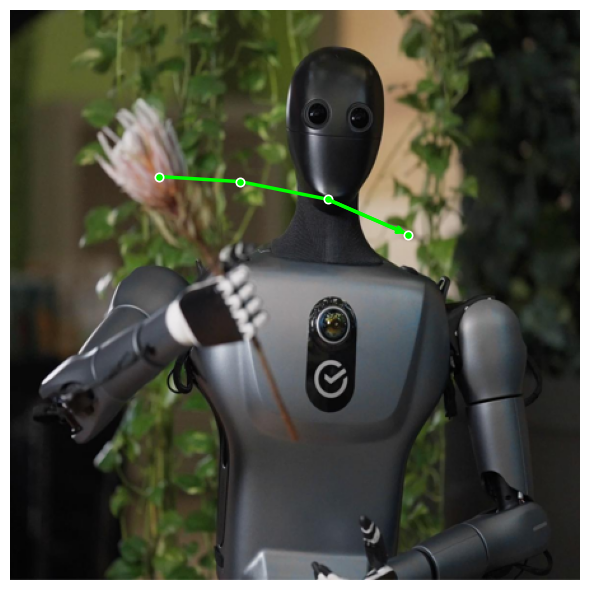

In [10]:
def plot_trajectory(image: Image.Image, detections: list[dict]) -> None:
    """Draw predicted 2D trajectory on the image.

    Args:
        image: The original PIL image.
        detections: List of dicts with ``trajectory_2d`` (list of [x, y] in 0-1000).
    """
    w, h = image.size

    fig, ax = plt.subplots(1, figsize=(6, 6))
    ax.imshow(image)

    for det in detections:
        points = det["trajectory_2d"]

        # Scale from 0-1000 normalised coords to actual pixel coords.
        xs = [p[0] / 1000 * w for p in points]
        ys = [p[1] / 1000 * h for p in points]

        # Draw the trajectory line with markers at each waypoint.
        ax.plot(xs, ys, marker="o", markersize=6, linewidth=2.5,
                markeredgecolor="white", markeredgewidth=1.2, color="lime")

        # Draw an arrow on the last segment to show direction.
        if len(xs) >= 2:
            ax.annotate("", xy=(xs[-1], ys[-1]), xytext=(xs[-2], ys[-2]),
                        arrowprops=dict(arrowstyle="->", color="lime", lw=2.5))

    ax.axis("off")
    plt.tight_layout()
    plt.show()


# Parse the answer from the previous cell and visualise.
trajectories = parse_bbox_answer(answer)  # same JSON wrapper
print("Trajectories:", trajectories)
plot_trajectory(img, trajectories)